<a href="https://colab.research.google.com/github/divya374r1/Neural-Network-and-Deep-Learning/blob/main/medical_image_exp_9%2CTransformers_exp_10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Epoch 1/2
1378/1378 ━━━━━━━━━━━━━━━━━━━━ 562s 405ms/step - accuracy: 0.8538 - loss: 0.3491 - val_accuracy: 0.9321 - val_loss: 0.2212
Epoch 2/2
1378/1378 ━━━━━━━━━━━━━━━━━━━━ 536s 389ms/step - accuracy: 0.9423 - loss: 0.1830 - val_accuracy: 0.9445 - val_loss: 0.1912


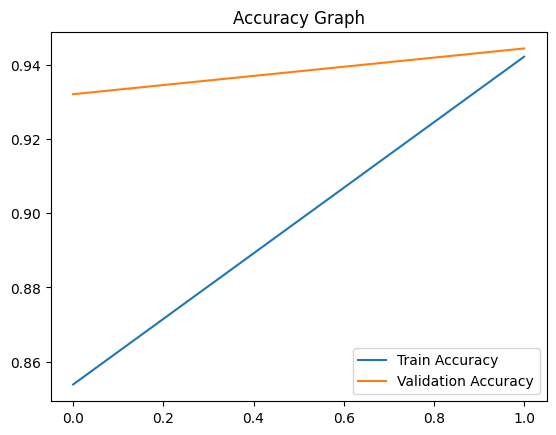

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step


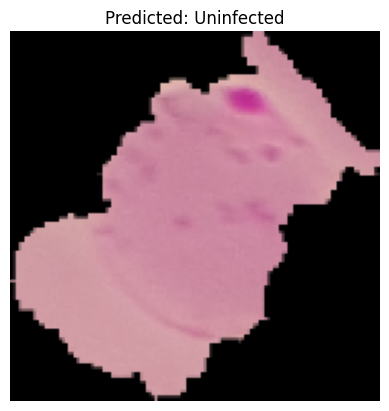

In [3]:
# =========================================
# EXPERIMENT 9: MEDICAL IMAGE CLASSIFICATION
# (INFECTED vs UNINFECTED)
# =========================================

# STEP 1: INSTALL DATASET
!pip install -q tensorflow-datasets

# STEP 2: IMPORT LIBRARIES
import tensorflow as tf
import tensorflow_datasets as tfds
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np

# STEP 3: LOAD MEDICAL DATASET
(ds_train, ds_test), ds_info = tfds.load(
    'malaria',
    split=['train[:80%]', 'train[80%:90%]'],
    as_supervised=True,
    with_info=True
)

# CLASS NAMES
class_names = ['Uninfected', 'Parasitized']

# STEP 4: PREPROCESS
def preprocess(image, label):
    image = tf.image.resize(image, (128, 128))
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

train_ds = ds_train.map(preprocess).batch(16)
val_ds = ds_test.map(preprocess).batch(16)

# STEP 5: BUILD CNN MODEL
model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)),
    layers.MaxPooling2D(),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(2, activation='softmax')
])

# STEP 6: COMPILE MODEL
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# STEP 7: TRAIN MODEL
history = model.fit(train_ds, validation_data=val_ds, epochs=2)

# STEP 8: ACCURACY GRAPH
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Accuracy Graph")
plt.show()

# STEP 9: TEST IMAGE + PREDICTION
for images, labels in val_ds.take(1):
    img = images[0]
    true_label = labels[0]
    break

img_input = tf.expand_dims(img, 0)

prediction = model.predict(img_input)
predicted_class = class_names[np.argmax(prediction)]

# STEP 10: DISPLAY OUTPUT
plt.imshow(img)
plt.title("Predicted: " + predicted_class)
plt.axis("off")
plt.show()

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Epoch 1/2
313/313 ━━━━━━━━━━━━━━━━━━━━ 143s 440ms/step - accuracy: 0.8061 - loss: 0.4059 - val_accuracy: 0.8708 - val_loss: 0.3021
Epoch 2/2
313/313 ━━━━━━━━━━━━━━━━━━━━ 138s 440ms/step - accuracy: 0.9171 - loss: 0.2138 - val_accuracy: 0.8780 - val_loss: 0.3200
782/782 ━━━━━━━━━━━━━━━━━━━━ 60s 77ms/step - accuracy: 0.8635 - loss: 0.3475
Test Accuracy: 0.8634799718856812
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 217ms/step
Predicted: Not Spam Email


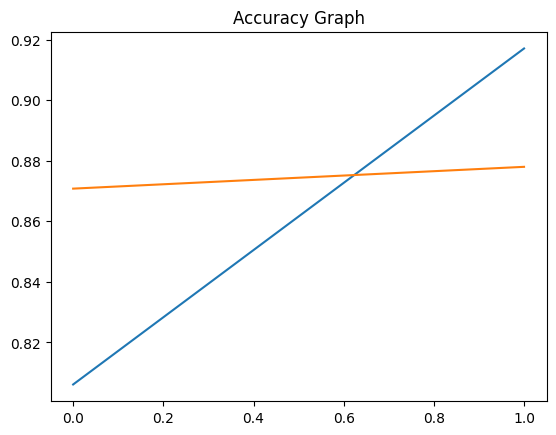

In [4]:

# EXPERIMENT 10: TRANSFORMER BASED EMAIL CLASSIFICATION

# STEP 1: IMPORT LIBRARIES
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np
import matplotlib.pyplot as plt

# STEP 2: LOAD DATASET (TEXT DATA)
vocab_size = 10000
max_len = 200

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.imdb.load_data(num_words=vocab_size)

# CONVERT TO TEXT FORMAT (simulate email classification)
x_train = tf.keras.preprocessing.sequence.pad_sequences(x_train, maxlen=max_len)
x_test = tf.keras.preprocessing.sequence.pad_sequences(x_test, maxlen=max_len)

# STEP 3: TRANSFORMER BLOCK
class TransformerBlock(layers.Layer):
    def __init__(self, embed_dim, num_heads, ff_dim):
        super().__init__()
        self.att = layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)
        self.ffn = models.Sequential([
            layers.Dense(ff_dim, activation="relu"),
            layers.Dense(embed_dim),
        ])
        self.layernorm1 = layers.LayerNormalization()
        self.layernorm2 = layers.LayerNormalization()
        self.dropout1 = layers.Dropout(0.1)
        self.dropout2 = layers.Dropout(0.1)

    def call(self, inputs):
        attn_output = self.att(inputs, inputs)
        attn_output = self.dropout1(attn_output)
        out1 = self.layernorm1(inputs + attn_output)
        ffn_output = self.ffn(out1)
        ffn_output = self.dropout2(ffn_output)
        return self.layernorm2(out1 + ffn_output)

# STEP 4: BUILD MODEL
embed_dim = 64
num_heads = 2
ff_dim = 64

inputs = layers.Input(shape=(max_len,))
embedding_layer = layers.Embedding(vocab_size, embed_dim)(inputs)

transformer_block = TransformerBlock(embed_dim, num_heads, ff_dim)
x = transformer_block(embedding_layer)

x = layers.GlobalAveragePooling1D()(x)
x = layers.Dense(64, activation="relu")(x)
outputs = layers.Dense(1, activation="sigmoid")(x)

model = models.Model(inputs=inputs, outputs=outputs)

# STEP 5: COMPILE
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# STEP 6: TRAIN
history = model.fit(
    x_train, y_train,
    epochs=2,
    batch_size=64,
    validation_split=0.2
)

# STEP 7: EVALUATE
loss, acc = model.evaluate(x_test, y_test)
print("Test Accuracy:", acc)

# STEP 8: PREDICTION
sample = x_test[0].reshape(1, -1)
pred = model.predict(sample)

if pred > 0.5:
    print("Predicted: Spam Email")
else:
    print("Predicted: Not Spam Email")

# STEP 9: GRAPH
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Accuracy Graph")
plt.show()